## SARIMA

In [1]:
# Import libraries
import warnings
import argparse
from pathlib import Path
from datetime import timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima import auto_arima

warnings.filterwarnings("ignore")

### Step1: Load the data

In [2]:
def load_cleaned_data(station_id, directory="./output"):
    filename = f"{directory}/Station{station_id}_filled_shortgaps.csv"
    df = pd.read_csv(filename, parse_dates=True, index_col=0)
    df.index = pd.DatetimeIndex(df.index)
    df.index.freq = 'H'
    return df

def load_missing_data(station_id, directory="../EDA_2025/missing_data"):
    filename = f"{directory}/Station{station_id}_missing_data.csv"
    df = pd.read_csv(filename, parse_dates=["Start Timestamp", "End Timestamp"])
    return df

In [3]:
load_cleaned_data(1).head()

,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Tair,RH,Wind speed,Wind direction,Srad,Ppt
2015-01-01 00:00:00,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,-1.090,81.5,1.052,52.27,0.63,0.0
2015-01-01 01:00:00,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,-1.038,81.7,0.959,46.71,0.62,0.0
2015-01-01 02:00:00,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,-0.981,82.0,1.062,52.04,0.60,0.0
2015-01-01 03:00:00,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,-0.814,81.9,0.887,58.91,0.64,0.0
2015-01-01 04:00:00,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,-0.805,90.0,0.828,16.55,0.20,0.0


### Step2: Filter Medium gap data for ARIMA (Days to Weeks) (1–7 days) (24–168 hours)

In [4]:
# Get medium gaps
def filter_medium_gaps(df_missing, parameter="SWC_5", min_gap=24, max_gap=168):
    # Convert "Number Missing" column to numeric
    df_missing["Number Missing"] = pd.to_numeric(df_missing["Number Missing"], errors="coerce")
    mask = (df_missing["Parameter"] == parameter) & \
           (df_missing["Number Missing"] >= min_gap) & (df_missing["Number Missing"] <= max_gap)
    return df_missing.loc[mask].sort_values("Start Timestamp")

### Step3: SARIMA Modeling and Imputation

In [5]:
# Fit SARIMAX model and predict missing values
def sarima_forecast(y, s_ts, e_ts, exog, ctx_days = 7, max_pq = 3, max_PQ = 2):
    # Determine the training window up to one hour before gap
    train_start = s_ts - timedelta(days=ctx_days)
    train_end = s_ts - timedelta(hours=1)

    # Extract and clean training data
    y_window = y.loc[train_start:train_end]
    y_train = y_window.dropna()
    if y_train.empty:
        print(f"[skip] No sufficient training data {train_start}–{train_end}")
        return None, None
    y_train.index = pd.DatetimeIndex(y_train.index, freq="H")

    # Prepare exogenous data
    X_train = X_pred = None
    if exog is not None:
        exog_window = exog.loc[train_start:train_end]
        X_train = exog_window.reindex(y_train.index).fillna(0)
        pred_index = pd.date_range(s_ts, e_ts, freq="H")
        X_pred = exog.reindex(pred_index).fillna(0)

    # Automatic model order selection with daily seasonality
    auto = auto_arima(
        y_train,
        exogenous=X_train,
        seasonal=True, m=24,
        d=None, D=1,
        start_p=1, start_q=1, max_p=max_pq, max_q=max_pq,
        start_P=0, start_Q=0, max_P=max_PQ, max_Q=max_PQ,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False
    )
    p, d, q = auto.order
    P, D, Q, s = auto.seasonal_order
    print(f"  → SARIMA({p},{d},{q})x({P},{D},{Q},{s})24h")

    # Fit the SARIMAX model with frequency parameter
    model = SARIMAX(
        y_train,
        exog=X_train,
        order=(p, d, q),
        seasonal_order=(P, D, Q, s),
        enforce_stationarity=False,
        enforce_invertibility=False,
        freq='H'
    )
    res = model.fit(method='powell', maxiter=300, disp=False)

    # Check residuals for autocorrelation
    lb_p = acorr_ljungbox(res.resid, lags=[24], return_df=True)["lb_pvalue"].iat[0]
    if lb_p < 0.05 and (max_pq < 5 or max_PQ < 3):
        # Retry with larger parameter bounds
        return sarima_forecast(
            y, s_ts, e_ts, exog,
            ctx_days=ctx_days,
            max_pq=max_pq+1,
            max_PQ=max_PQ+1
        )

    # Forecast the gap interval
    forecast_index = pd.date_range(s_ts, e_ts, freq="H")
    fc = res.forecast(steps=len(forecast_index), exog=X_pred)
    fc.index = forecast_index
    return fc, res

In [6]:
# Plain ARIMA
def arima_forecast(y, s_ts, e_ts, ctx_days=7, max_pq=3):
    train_start = s_ts - timedelta(days=ctx_days)
    train_end   = s_ts - timedelta(hours=1)
    y_train = y.loc[train_start:train_end].dropna()
    if y_train.empty:
        print(f"[skip] no data {train_start}–{train_end}")
        return None, None
    y_train.index = pd.DatetimeIndex(y_train.index, freq="H")

    auto = auto_arima(
        y_train,
        seasonal=False,
        d=None,
        start_p=1, start_q=1, max_p=max_pq, max_q=max_pq,
        stepwise=True, error_action="ignore", suppress_warnings=True
    )
    p, d, q = auto.order
    print(f"  → ARIMA({p},{d},{q})")

    model = SARIMAX(
        y_train,
        order=(p, d, q),
        seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False,
        freq='H'
    )
    res = model.fit(method='powell', maxiter=300, disp=False)

    idx = pd.date_range(s_ts, e_ts, freq="H")
    fc  = res.forecast(steps=len(idx))
    fc.index = idx
    return fc, res

### Step4: Visualize the Imputation Result

In [7]:
# Show model residuals and autocorrelation
def quick_diag(res, lag = 24):
    """
    Display residuals plot, ACF plot, and Ljung-Box p-value for diagnostic.
    """
    pvalue = acorr_ljungbox(res.resid, lags=[lag], return_df=True)["lb_pvalue"].iat[0]
    print(f"Ljung-Box p @ lag {lag} = {pvalue:.3g}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 2.8))
    axes[0].plot(res.resid); axes[0].set_title("Residuals")
    plot_acf(res.resid, lags=lag, ax=axes[1])
    plt.tight_layout(); plt.show()
    
def plot_gap(series, s_ts, e_ts):
    """
    Plot the imputed series around the gap for visual inspection.
    """
    window = series.loc[s_ts - timedelta(days=3): e_ts + timedelta(days=3)]
    plt.figure(figsize=(10, 3.5))
    plt.plot(window, label="Filled Series")
    plt.axvspan(s_ts, e_ts, color='grey', alpha=0.3, label="Gap")
    plt.title(f"{series.name}: {s_ts} → {e_ts}")
    plt.legend(); plt.tight_layout(); plt.show()


### Step5: Main Function

In [8]:
def main(station, param = "SWC_20", extra_days = 7):
    df = load_cleaned_data(station)
    df_ref = load_cleaned_data(3)
    exog = df["Ppt"].fillna(df_ref["Ppt"]).fillna(0)

    gaps_tbl = load_missing_data(station)
    gaps = filter_medium_gaps(gaps_tbl, param)
    if gaps.empty:
        print("No 1–7 day gaps to impute.")
        return

    print(gaps[["Start Timestamp", "End Timestamp", "Number Missing"]])
    for _, row in gaps.iterrows():
        s_ts, e_ts = row["Start Timestamp"], row["End Timestamp"]
        print(f"\n Imputing {s_ts} – {e_ts}")

        fc, res = sarima_forecast(df[param], s_ts, e_ts, exog, ctx_days=extra_days)
        if fc is None:
            continue

        # Smooth edges between original and predicted values
        if (s_ts - timedelta(hours=1)) in df.index:
            left_val = df.at[s_ts - timedelta(hours=1), param]
            fc.iloc[0] = 0.5 * (left_val + fc.iloc[0])
        if (e_ts + timedelta(hours=1)) in df.index:
            right_val = df.at[e_ts + timedelta(hours=1), param]
            fc.iloc[-1] = 0.5 * (right_val + fc.iloc[-1])

        df.loc[fc.index, param] = fc
        quick_diag(res)
        plot_gap(df[param], s_ts, e_ts)

    output_fp = f"Station{station}_{param}_filled_mediumgaps.csv"
    df.to_csv(output_fp)
    print(f"\n Saved → {output_fp}")

       Start Timestamp       End Timestamp  Number Missing
38 2017-06-09 09:00:00 2017-06-12 02:00:00              66
43 2017-07-01 14:00:00 2017-07-06 07:00:00             114

 Imputing 2017-06-09 09:00:00 – 2017-06-12 02:00:00
  → SARIMA(0,1,1)x(0,1,2,24)24h
  → SARIMA(0,1,1)x(0,1,2,24)24h
  → SARIMA(0,1,1)x(0,1,2,24)24h
Ljung-Box p @ lag 24 = 0.00959


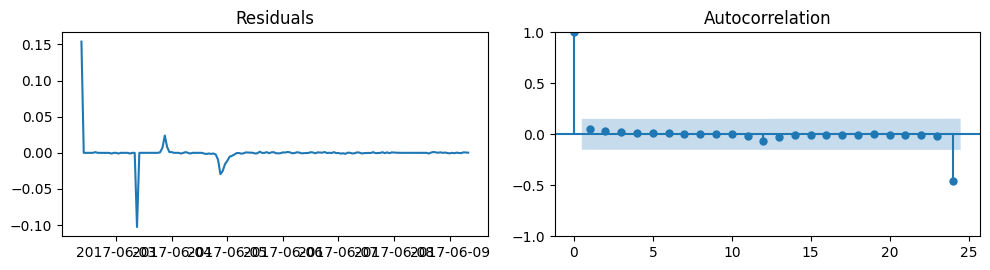

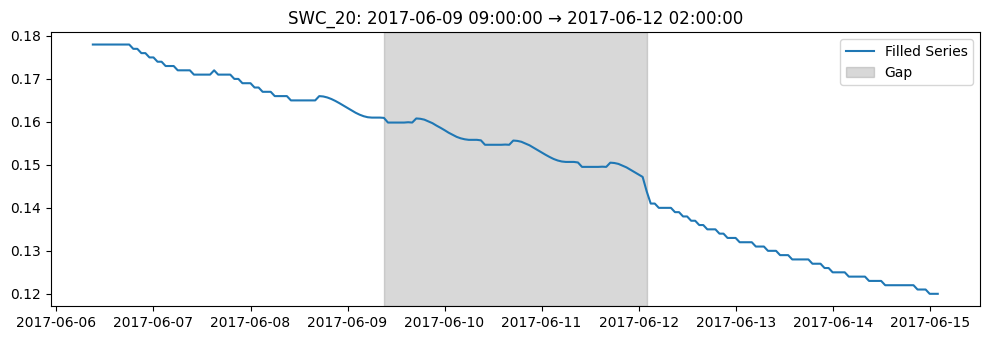


 Imputing 2017-07-01 14:00:00 – 2017-07-06 07:00:00
  → SARIMA(2,1,0)x(2,1,1,24)24h
Ljung-Box p @ lag 24 = 0.458


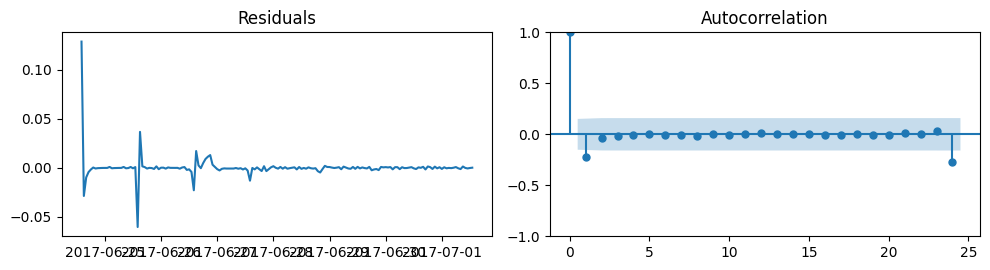

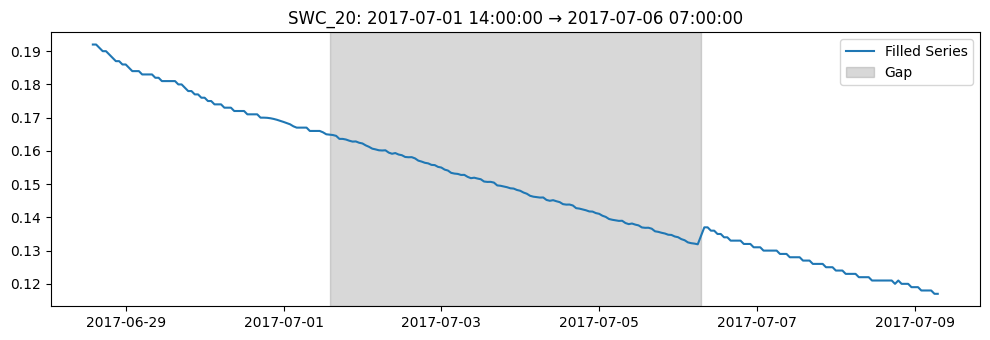


 Saved → Station1_SWC_20_filled_mediumgaps.csv


In [13]:
main(station=1, param="SWC_20", extra_days=7)

## Spring

Masking 2018-03-15 00:00:00 – 2018-03-17 23:00:00 (72 h)
  → SARIMA(0,1,1)x(2,1,0,24)24h
  → ARIMA(1,2,3)
SARIMA - MAE = 0.0024,  RMSE = 0.0027
ARIMA - MAE = 0.0028, RMSE = 0.0032


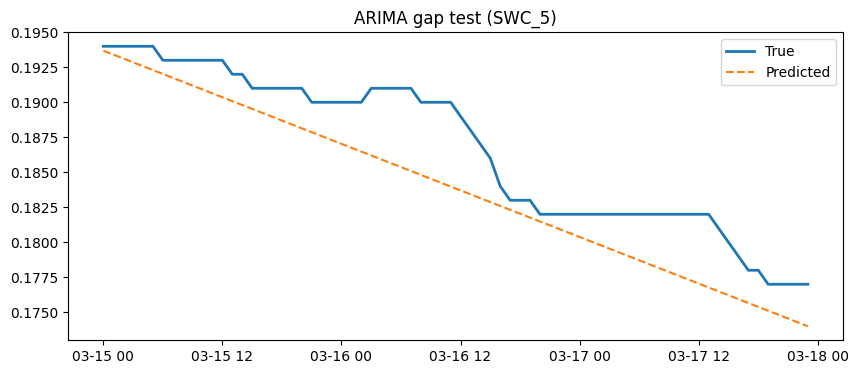

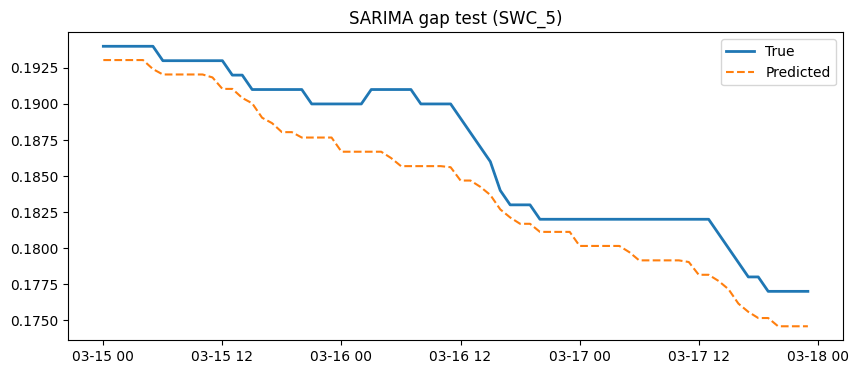

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
df_full = load_cleaned_data(2)      
param   = "SWC_5"
test_start = pd.Timestamp("2018-03-15 00:00")   
gap_hours  = 72                                 
test_end   = test_start + timedelta(hours=gap_hours-1)

print(f"Masking {test_start} – {test_end} ({gap_hours} h)")


y_true = df_full[param].loc[test_start:test_end].copy()

df_tmp = df_full.copy()
df_tmp.loc[test_start:test_end, param] = np.nan     


df_ref = load_cleaned_data(3)
exog = df_tmp["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
y_pred, fitted = sarima_forecast(
    y=df_tmp[param], 
    s_ts=test_start, 
    e_ts=test_end, 
    exog=exog,
    ctx_days=7  
)

y_arima, fitted_a = arima_forecast(
    y=df_tmp[param],
    s_ts=test_start,
    e_ts=test_end,
    ctx_days=7
)

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

mae_a  = mean_absolute_error(y_true, y_arima)
rmse_a = mean_squared_error(y_true, y_arima, squared=False)

print(f"SARIMA - MAE = {mae:.4f},  RMSE = {rmse:.4f}")
print(f"ARIMA - MAE = {mae_a:.4f}, RMSE = {rmse_a:.4f}")

plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_arima, label="Predicted", linestyle="--")
plt.title(f"ARIMA gap test ({param})")
plt.legend(); plt.show()


plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title(f"SARIMA gap test ({param})")
plt.legend(); plt.show()

Masking 2017-03-15 00:00:00 – 2017-03-17 23:00:00 (72 h)
  → SARIMA(0,1,1)x(0,1,1,24)24h
  → SARIMA(0,1,1)x(0,1,1,24)24h
  → SARIMA(0,1,1)x(0,1,1,24)24h
  → ARIMA(3,1,0)
SARIMA - MAE = 0.0024,  RMSE = 0.0027
ARIMA - MAE = 0.0047, RMSE = 0.0053


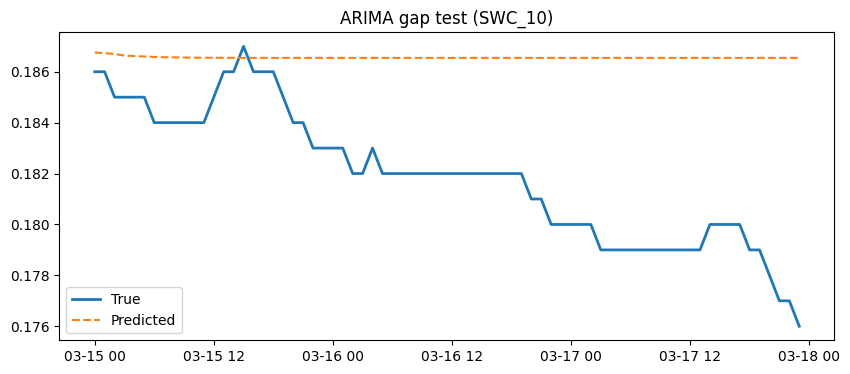

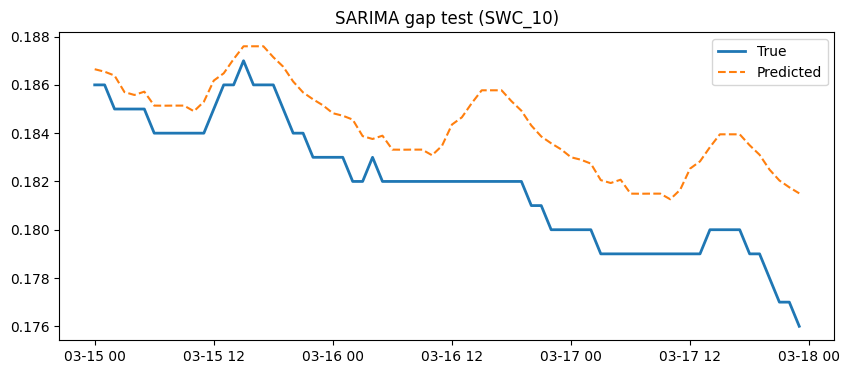

In [13]:
df_full = load_cleaned_data(1)      
param   = "SWC_10"
test_start = pd.Timestamp("2017-03-15 00:00")   
gap_hours  = 72                                 
test_end   = test_start + timedelta(hours=gap_hours-1)

print(f"Masking {test_start} – {test_end} ({gap_hours} h)")


y_true = df_full[param].loc[test_start:test_end].copy()

df_tmp = df_full.copy()
df_tmp.loc[test_start:test_end, param] = np.nan     


df_ref = load_cleaned_data(3)
exog = df_tmp["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
y_pred, fitted = sarima_forecast(
    y=df_tmp[param], 
    s_ts=test_start, 
    e_ts=test_end, 
    exog=exog,
    ctx_days=7  
)

y_arima, fitted_a = arima_forecast(
    y=df_tmp[param],
    s_ts=test_start,
    e_ts=test_end,
    ctx_days=7
)

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

mae_a  = mean_absolute_error(y_true, y_arima)
rmse_a = mean_squared_error(y_true, y_arima, squared=False)

print(f"SARIMA - MAE = {mae:.4f},  RMSE = {rmse:.4f}")
print(f"ARIMA - MAE = {mae_a:.4f}, RMSE = {rmse_a:.4f}")

plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_arima, label="Predicted", linestyle="--")
plt.title(f"ARIMA gap test ({param})")
plt.legend(); plt.show()


plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title(f"SARIMA gap test ({param})")
plt.legend(); plt.show()

Masking 2017-03-15 00:00:00 – 2017-03-17 23:00:00 (72 h)
  → SARIMA(1,0,1)x(0,1,0,24)24h
  → SARIMA(1,0,1)x(0,1,0,24)24h
  → SARIMA(1,0,1)x(0,1,0,24)24h
MAE = 0.0011,  RMSE = 0.0015


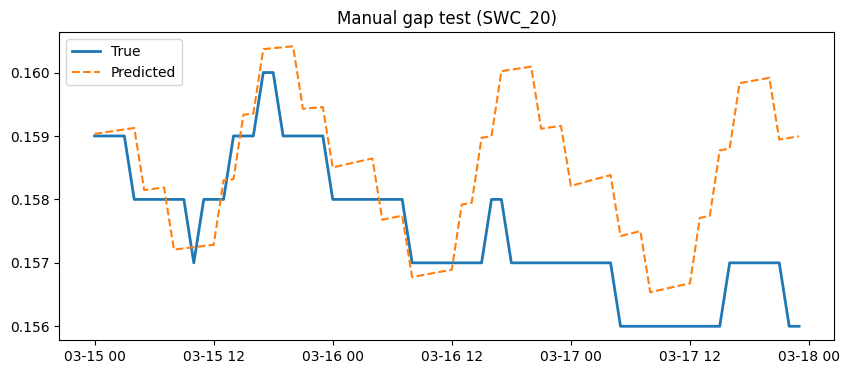

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
df_full = load_cleaned_data(1)      
param   = "SWC_20"
test_start = pd.Timestamp("2017-03-15 00:00")   
gap_hours  = 72                                 
test_end   = test_start + timedelta(hours=gap_hours-1)

print(f"Masking {test_start} – {test_end} ({gap_hours} h)")


y_true = df_full[param].loc[test_start:test_end].copy()

df_tmp = df_full.copy()
df_tmp.loc[test_start:test_end, param] = np.nan     


df_ref = load_cleaned_data(3)
exog = df_tmp["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
y_pred, fitted = sarima_forecast(
    y=df_tmp[param], 
    s_ts=test_start, 
    e_ts=test_end, 
    exog=exog,
    ctx_days=7  
)



mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)
print(f"MAE = {mae:.4f},  RMSE = {rmse:.4f}")


plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title(f"Manual gap test ({param})")
plt.legend(); plt.show()  

Masking 2019-03-15 00:00:00 – 2019-03-17 23:00:00 (72 h)
  → SARIMA(0,1,0)x(0,1,1,24)24h
  → SARIMA(0,1,0)x(0,1,1,24)24h
  → SARIMA(0,1,0)x(0,1,1,24)24h
MAE = 0.0010,  RMSE = 0.0011


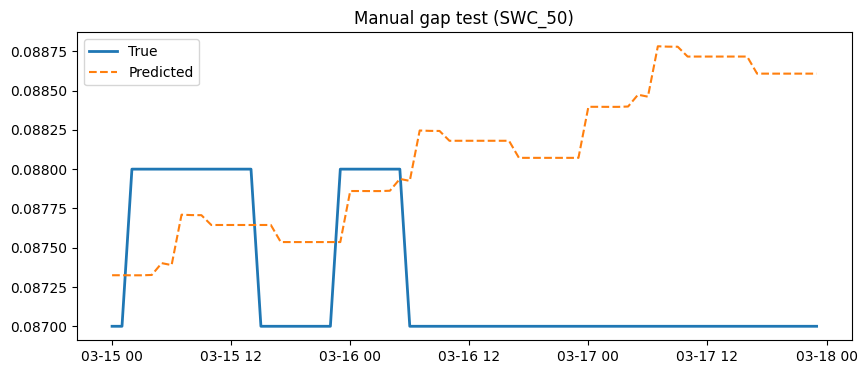

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
df_full = load_cleaned_data(6)      
param   = "SWC_50"
test_start = pd.Timestamp("2019-03-15 00:00")   
gap_hours  = 72                                 
test_end   = test_start + timedelta(hours=gap_hours-1)

print(f"Masking {test_start} – {test_end} ({gap_hours} h)")


y_true = df_full[param].loc[test_start:test_end].copy()

df_tmp = df_full.copy()
df_tmp.loc[test_start:test_end, param] = np.nan     


df_ref = load_cleaned_data(3)
exog = df_tmp["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
y_pred, fitted = sarima_forecast(
    y=df_tmp[param], 
    s_ts=test_start, 
    e_ts=test_end, 
    exog=exog,
    ctx_days=7  
)



mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)
print(f"MAE = {mae:.4f},  RMSE = {rmse:.4f}")


plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title(f"Manual gap test ({param})")
plt.legend(); plt.show()  

## Summer

Masking 2019-06-10 00:00:00 – 2019-06-12 23:00:00 (72 h)
  → SARIMA(1,0,2)x(0,1,0,24)24h
  → SARIMA(1,0,2)x(0,1,0,24)24h
  → SARIMA(1,0,2)x(0,1,0,24)24h
MAE = 0.0892,  RMSE = 0.0981


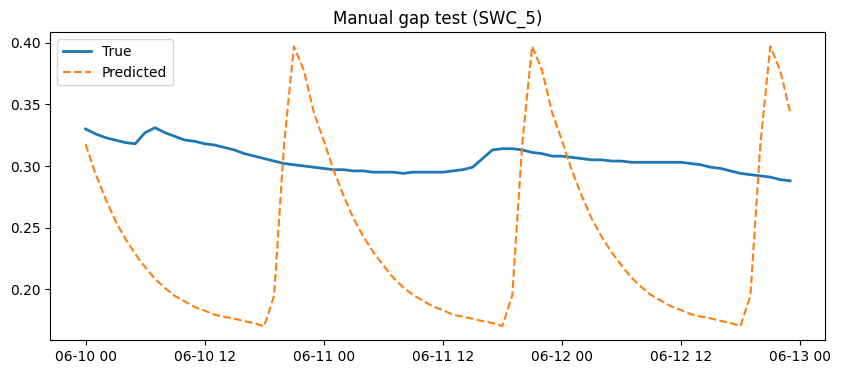

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
df_full = load_cleaned_data(4)      
param   = "SWC_5"
test_start = pd.Timestamp("2019-06-10 00:00")   
gap_hours  = 72                                 
test_end   = test_start + timedelta(hours=gap_hours-1)

print(f"Masking {test_start} – {test_end} ({gap_hours} h)")


y_true = df_full[param].loc[test_start:test_end].copy()

df_tmp = df_full.copy()
df_tmp.loc[test_start:test_end, param] = np.nan     


df_ref = load_cleaned_data(3)
exog = df_tmp["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
y_pred, fitted = sarima_forecast(
    y=df_tmp[param], 
    s_ts=test_start, 
    e_ts=test_end, 
    exog=exog,
    ctx_days=7  
)



mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)
print(f"MAE = {mae:.4f},  RMSE = {rmse:.4f}")


plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title(f"Manual gap test ({param})")
plt.legend(); plt.show()  

Masking 2019-06-10 00:00:00 – 2019-06-12 23:00:00 (72 h)
  → SARIMA(0,1,2)x(0,1,1,24)24h
  → SARIMA(0,1,2)x(0,1,1,24)24h
  → SARIMA(0,1,2)x(0,1,1,24)24h
MAE = 0.0014,  RMSE = 0.0016


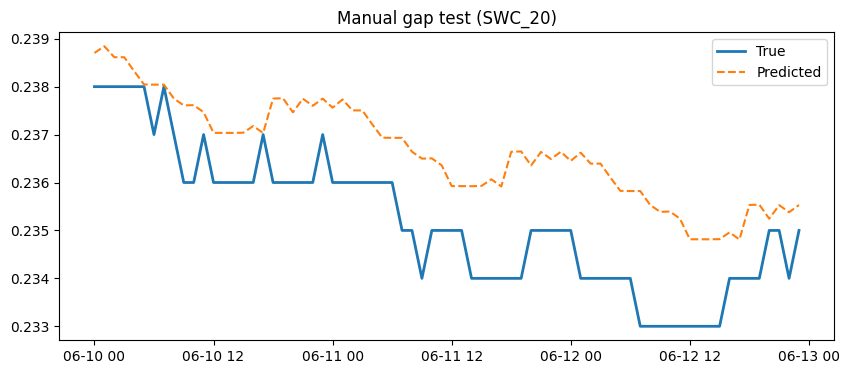

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
df_full = load_cleaned_data(5)      
param   = "SWC_20"
test_start = pd.Timestamp("2019-06-10 00:00")   
gap_hours  = 72                                 
test_end   = test_start + timedelta(hours=gap_hours-1)

print(f"Masking {test_start} – {test_end} ({gap_hours} h)")


y_true = df_full[param].loc[test_start:test_end].copy()

df_tmp = df_full.copy()
df_tmp.loc[test_start:test_end, param] = np.nan     


df_ref = load_cleaned_data(3)
exog = df_tmp["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
y_pred, fitted = sarima_forecast(
    y=df_tmp[param], 
    s_ts=test_start, 
    e_ts=test_end, 
    exog=exog,
    ctx_days=7  
)



mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)
print(f"MAE = {mae:.4f},  RMSE = {rmse:.4f}")


plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title(f"Manual gap test ({param})")
plt.legend(); plt.show()  

## Autumn

Masking 2017-10-10 00:00:00 – 2017-10-12 23:00:00 (72 h)
  → SARIMA(0,1,1)x(0,1,1,24)24h
  → SARIMA(0,1,1)x(0,1,1,24)24h
  → SARIMA(0,1,1)x(0,1,1,24)24h
MAE = 0.0017,  RMSE = 0.0018


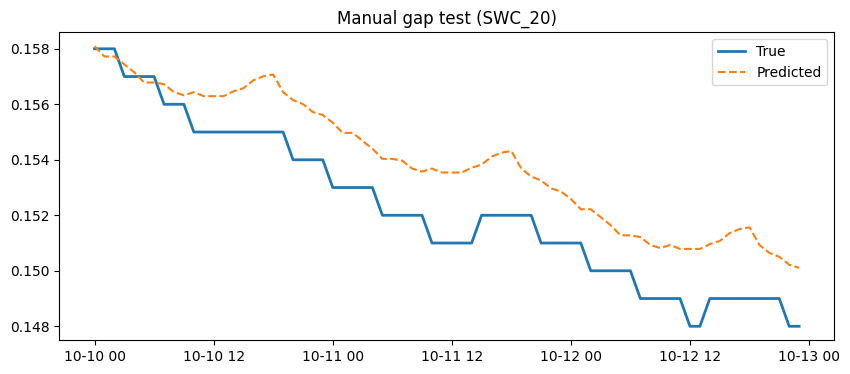

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
df_full = load_cleaned_data(1)      
param   = "SWC_20"
test_start = pd.Timestamp("2017-10-10 00:00")   
gap_hours  = 72                                 
test_end   = test_start + timedelta(hours=gap_hours-1)

print(f"Masking {test_start} – {test_end} ({gap_hours} h)")


y_true = df_full[param].loc[test_start:test_end].copy()

df_tmp = df_full.copy()
df_tmp.loc[test_start:test_end, param] = np.nan     


df_ref = load_cleaned_data(3)
exog = df_tmp["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
y_pred, fitted = sarima_forecast(
    y=df_tmp[param], 
    s_ts=test_start, 
    e_ts=test_end, 
    exog=exog,
    ctx_days=7  
)



mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)
print(f"MAE = {mae:.4f},  RMSE = {rmse:.4f}")


plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title(f"Manual gap test ({param})")
plt.legend(); plt.show()  

Masking 2017-10-10 00:00:00 – 2017-10-12 23:00:00 (72 h)
  → SARIMA(0,1,0)x(2,1,1,24)24h
MAE = 0.0016,  RMSE = 0.0019


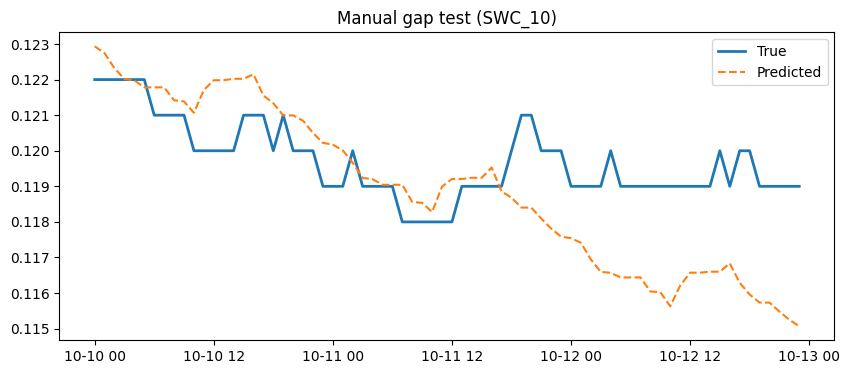

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
df_full = load_cleaned_data(6)      
param   = "SWC_10"
test_start = pd.Timestamp("2017-10-10 00:00")   
gap_hours  = 72                                 
test_end   = test_start + timedelta(hours=gap_hours-1)

print(f"Masking {test_start} – {test_end} ({gap_hours} h)")


y_true = df_full[param].loc[test_start:test_end].copy()

df_tmp = df_full.copy()
df_tmp.loc[test_start:test_end, param] = np.nan     


df_ref = load_cleaned_data(3)
exog = df_tmp["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
y_pred, fitted = sarima_forecast(
    y=df_tmp[param], 
    s_ts=test_start, 
    e_ts=test_end, 
    exog=exog,
    ctx_days=7  
)



mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)
print(f"MAE = {mae:.4f},  RMSE = {rmse:.4f}")


plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title(f"Manual gap test ({param})")
plt.legend(); plt.show()  

## Winter

Masking 2018-01-10 00:00:00 – 2018-01-12 23:00:00 (72 h)
  → SARIMA(0,1,0)x(0,1,0,24)24h
  → SARIMA(0,1,0)x(0,1,0,24)24h
  → SARIMA(0,1,0)x(0,1,0,24)24h
MAE = 0.0006,  RMSE = 0.0008


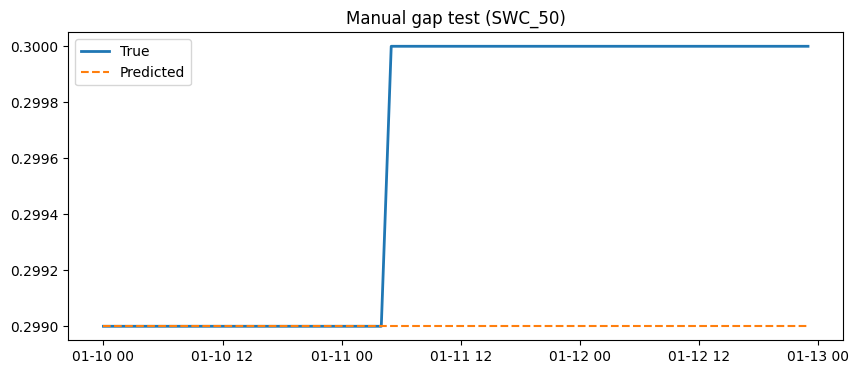

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
df_full = load_cleaned_data(2)      
param   = "SWC_50"
test_start = pd.Timestamp("2018-01-10 00:00")   
gap_hours  = 72                                 
test_end   = test_start + timedelta(hours=gap_hours-1)

print(f"Masking {test_start} – {test_end} ({gap_hours} h)")


y_true = df_full[param].loc[test_start:test_end].copy()

df_tmp = df_full.copy()
df_tmp.loc[test_start:test_end, param] = np.nan     


df_ref = load_cleaned_data(3)
exog = df_tmp["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
y_pred, fitted = sarima_forecast(
    y=df_tmp[param], 
    s_ts=test_start, 
    e_ts=test_end, 
    exog=exog,
    ctx_days=7  
)



mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)
print(f"MAE = {mae:.4f},  RMSE = {rmse:.4f}")


plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title(f"Manual gap test ({param})")
plt.legend(); plt.show()  

Masking 2017-10-10 00:00:00 – 2017-10-12 23:00:00 (72 h)
  → SARIMA(0,1,1)x(1,1,1,24)24h
MAE = 0.0008,  RMSE = 0.0010


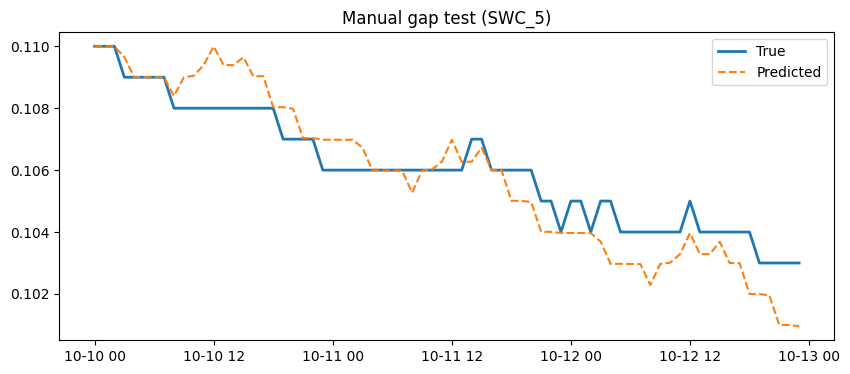

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
df_full = load_cleaned_data(6)      
param   = "SWC_5"
test_start = pd.Timestamp("2017-10-10 00:00")   
gap_hours  = 72                                 
test_end   = test_start + timedelta(hours=gap_hours-1)

print(f"Masking {test_start} – {test_end} ({gap_hours} h)")


y_true = df_full[param].loc[test_start:test_end].copy()

df_tmp = df_full.copy()
df_tmp.loc[test_start:test_end, param] = np.nan     


df_ref = load_cleaned_data(3)
exog = df_tmp["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
y_pred, fitted = sarima_forecast(
    y=df_tmp[param], 
    s_ts=test_start, 
    e_ts=test_end, 
    exog=exog,
    ctx_days=7  
)



mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)
print(f"MAE = {mae:.4f},  RMSE = {rmse:.4f}")


plt.figure(figsize=(10,4))
plt.plot(y_true, label="True", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title(f"Manual gap test ({param})")
plt.legend(); plt.show()  